Aqui vamos a trabajar todas las máquinas con las que cuentan en la empresa. 

La tabla que contiene las maquinas pertenece al sistema MES, esta muestra todos los NODOS desde los que es posible realizar imputaciones. Entendemos como nodo cualquier entidad que permita capturar datos y que represente un lugar de trabajo de la planta, por ende, un nodo puede ser una máquina, pero tambien puede ser un centro de trabajo, un despacho, o cualquier cosa desde la que se quiera capturar el estado de la producción. 

In [240]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np 
import pyarrow as pa

In [241]:
ruta_nodos = os.path.join("res\\raw", "SmNodo.csv")
print(ruta_nodos)

res\raw\SmNodo.csv


In [242]:
columns_SmNodo = ["SmNodoUid",	"smNodoId",	"smNodoCodigoGestion",	"smNodoNme",	"smNodoDsc", 	"smEstructuraUid", "padre_smNodoUid",	"presenciaEnPlantaInd",	"smNodoPersonalizado1Dte",	"smNodoPersonalizado2Dte",	"smNodoPersonalizado1Nbr",	"smNodoPersonalizado2Nbr",	"smNodoPersonalizado1Txt",	"smNodoPersonalizado2Txt",	"EsMaquinaOlanetInd",	"bajaInd",	"guardarTimestampPiezaInd",	"FechaUltimaActualizacionDte",	"Planta",	"modificadoPor_usuario_guid",	"FechaCreacionDte",	"Ortems_smNodoPersonalizado1Txt",	"Ortems_smNodoPersonalizado2Txt",	"ssEnumTipoVerticalId"]

pd.set_option("display.max_columns", None)  
pd.set_option("display.width", None)        

df_nodos = pd.read_csv(ruta_nodos, sep=";", header=None, names=columns_SmNodo)

In [243]:
print(df_nodos.shape)

(119, 24)


In [244]:
display(df_nodos.sample(5))

,SmNodoUid,smNodoId,smNodoCodigoGestion,smNodoNme,smNodoDsc,smEstructuraUid,padre_smNodoUid,presenciaEnPlantaInd,smNodoPersonalizado1Dte,smNodoPersonalizado2Dte,smNodoPersonalizado1Nbr,smNodoPersonalizado2Nbr,smNodoPersonalizado1Txt,smNodoPersonalizado2Txt,EsMaquinaOlanetInd,bajaInd,guardarTimestampPiezaInd,FechaUltimaActualizacionDte,Planta,modificadoPor_usuario_guid,FechaCreacionDte,Ortems_smNodoPersonalizado1Txt,Ortems_smNodoPersonalizado2Txt,ssEnumTipoVerticalId
11,F5DE875E-230B-4BC3-95E2-155388637337,ME,NaN,Montatge Elèctric,NaN,77B561BE-739E-40E7-BF85-5E145FD9B073,FE7C7762-7935-474B-8DD9-8B65963A2F81,0,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,2024-12-09 12:25:52.407,DESARROLLO,NaN,2024-11-29 16:47:23.940,NaN,NaN,NaN
58,656E1B86-5546-4354-9941-74BE97C5C3F6,TN04,NaN,TPG DAEWOO PUMA 400L (TPG) Torn C.N.C,NaN,A9FDD6C6-9347-4574-AA8B-AFFC559C4D9D,CA4A32B7-6CA0-48EB-8832-87A52F459AC2,0,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,2025-04-04 09:51:10.000,DESARROLLO,NaN,2024-11-29 16:52:04.290,NaN,NaN,NaN
22,E82C9BE9-68C8-43AE-A9A4-35202C1461AB,CM13,NaN,CT ROB T21 ROBODRILL,NaN,A9FDD6C6-9347-4574-AA8B-AFFC559C4D9D,03E48433-A524-4BB5-848E-EBEF469898D5,0,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,2025-04-04 08:11:19.000,DESARROLLO,NaN,2024-11-29 16:41:55.803,NaN,NaN,NaN
101,1B2B026B-3F49-4731-AB6F-D27D1F3BCC68,PR07,NaN,CAM CU 04,NaN,A9FDD6C6-9347-4574-AA8B-AFFC559C4D9D,1B0B9881-74A9-4863-A999-DA09CABDB23E,0,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,2025-11-21 10:26:34.000,DESARROLLO,NaN,2025-05-22 11:26:15.453,NaN,NaN,NaN
78,6572B9DD-DBC9-4ECF-B355-9518E6F87571,CM05,NaN,CH MAK. a81,NaN,A9FDD6C6-9347-4574-AA8B-AFFC559C4D9D,CEB8F912-87C8-44F8-A269-5E83ABED4067,0,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,2025-04-04 07:59:09.000,DESARROLLO,NaN,2024-11-29 16:40:05.217,NaN,NaN,NaN


Entonces contamos con 119 nodos, de los cuales solo queremos acabar trabajando con los que sean máquinas. 

Vamos a trabajar con las maquinas desde ERP, ahí podemos ver como las agrupan. Una máquina solo puede pertenecer a un único grupo.    

Tenemos tres tablas:
- df_machines: donde vemos todas las máquinas de ERP (coincidirán con los NODOS de MES, la tabla SmNodo).
- df_machines_group: donde vemos todos los grupos de máquinas de ERP.
- df_machines_relaciones: podemos ver a que grupo pertenece cada máquina.

In [245]:
ruta_machines = os.path.join("res\\raw", "CPRMachine.csv")
print(ruta_machines)

ruta_machines_group = os.path.join("res\\raw", "CPRMachineGroup.csv")
print(ruta_machines_group)

ruta_machines_relaciones = os.path.join("res\\raw", "CPRMachineGroupElement.csv")
print(ruta_machines_relaciones)

res\raw\CPRMachine.csv
res\raw\CPRMachineGroup.csv
res\raw\CPRMachineGroupElement.csv


In [246]:
columns_CPRMachine = ["IDMachine",	"CodCompany",	"CodMachine",	"Description",	"CostType",	"IDMeasureUnit",	"BottleNeck",	"Image",	"IDCalendar",	"PosX",	"PosY",	"Fictitious",	"InactivateDate",	"IDSite",	"RowTimestamp",	"LastModifiedBy",	"ImputationOnLineUnique",	"AllowMultiImputation",	"CreationTimestamp",	"RowCreatedBy",	"DisplayOrder"]
columns_CPRMachineGroup = ["IDMachineGroup",	"CodCompany",	"CodMachineGroup",	"Description",	"Infinite",	"IDCalendar",	"IDSite",	"RowTimestamp",	"BottleNeck",	"LastModifiedBy",	"KeepResource",	"CreationTimestamp",	"RowCreatedBy",	"CalendarType"]
columns_CPRMachineGroupElement = ["IDMachineGroupElement",	"CodCompany",	"IDMachineGroup",	"IDMachine",	"Priority",	"Alternative",	"RowTimestamp",	"LastModifiedBy",	"CreationTimestamp",	"RowCreatedBy"]

pd.set_option("display.max_columns", None)  
pd.set_option("display.width", None)        

df_machines = pd.read_csv(ruta_machines, sep=";", header=None, names=columns_CPRMachine)
df_machines_group = pd.read_csv(ruta_machines_group, sep=";", header=None, names=columns_CPRMachineGroup)
df_machines_relaciones = pd.read_csv(ruta_machines_relaciones, sep=";", header=None, names=columns_CPRMachineGroupElement)

Solo trabajaremos con las máquinas que pertenezcan a la planta 100

In [247]:
df_machines = df_machines[df_machines["CodCompany"] == 100]
df_machines_group = df_machines_group[df_machines_group["CodCompany"] == 100]
df_machines_relaciones = df_machines_relaciones[df_machines_relaciones["CodCompany"] == 100]

In [248]:
print(df_machines.shape)
print(df_machines_group.shape)
print(df_machines_relaciones.shape)

(120, 21)
(57, 14)
(115, 10)


In [249]:
display(df_machines.head(1))
display(df_machines_group.head(1))
display(df_machines_relaciones.head(1))

,IDMachine,CodCompany,CodMachine,Description,CostType,IDMeasureUnit,BottleNeck,Image,IDCalendar,PosX,PosY,Fictitious,InactivateDate,IDSite,RowTimestamp,LastModifiedBy,ImputationOnLineUnique,AllowMultiImputation,CreationTimestamp,RowCreatedBy,DisplayOrder
0,01672179-5f64-497a-a94b-5005cd1dd366,100,TL01,T.IBARNIA 50 CA Taladre,1,NaN,0,NaN,3482414a-2dbf-4988-85be-173350cb4280,-1.0,-1.0,0,NaN,NaN,2026-03-02 11:04:01.650,consultor,0,0,2024-02-29 12:32:24.347,consultor,0


,IDMachineGroup,CodCompany,CodMachineGroup,Description,Infinite,IDCalendar,IDSite,RowTimestamp,BottleNeck,LastModifiedBy,KeepResource,CreationTimestamp,RowCreatedBy,CalendarType
0,00d98579-bf94-4d66-9b77-b55cbb8e9796,100,INC-FLE-AL,INC. FLEXIBLES ALUMINI,0,ef53d58c-19a4-40c1-a89b-2b272fb513bf,NaN,2026-03-02 10:47:40.760,0,consultor,0,2025-09-24 15:59:18.553,IDOM,1


,IDMachineGroupElement,CodCompany,IDMachineGroup,IDMachine,Priority,Alternative,RowTimestamp,LastModifiedBy,CreationTimestamp,RowCreatedBy
0,00308d61-f8a3-4530-8a13-f1d453972ce9,100,7d29197b-e1a1-4c19-bf95-7fa3b96ed500,a045db52-b7d0-4011-b402-e7f63d5e4d3a,1,0,2025-08-08 09:36:18.693,ASOL,2024-04-04 15:10:31.000,ASOL


Reviso que las maquinas de `df_machines` (ERP) coincidan con las de `df_nodos` (MES).

In [250]:
compara = df_machines.merge(df_nodos, left_on="CodMachine", right_on="smNodoId", how="outer", indicator=True)\
.query("_merge != 'both'")\

solo_en_df_machines = compara[compara["_merge"] == "left_only"]  # maquinas que estan en ERP pero no en MES 
solo_en_df_nodos = compara[compara["_merge"] == "right_only"] # maquinas que estan en MES pero no en ERP

lista_solo_machines = solo_en_df_machines["CodMachine"].tolist()
lista_solo_nodos = solo_en_df_nodos["smNodoId"].tolist()

if lista_solo_machines:
    print(f"Máquinas en ERP pero no en MES: {lista_solo_machines}")
else:
    print("No hay máquinas en ERP que no estén en MES")

if lista_solo_nodos:
    print(f"Máquinas en MES pero no en ERP: {lista_solo_nodos}")
else:
    print("No hay máquinas en MES que no estén en ERP")

Máquinas en ERP pero no en MES: ['TU06']
No hay máquinas en MES que no estén en ERP


> Estas máquinas que no estan en MES debo eliminarlas de la tabla `df_machines`, si no estan en MES no pueden recivir imputaciones. Por lo general estas maquinas se han dado de baja o sirven para asuntos de ERP sin interesar que vivan en el mundo de MES. El descarte es facil, mi proyecto busca trabajar con máquinas que permitan imputaciones. 

In [251]:
df_machines = df_machines[~df_machines["CodMachine"].isin(lista_solo_machines)]
print(df_machines.shape)

(119, 21)


## Agrupar las maquinas
Procedo a crear uan tabla que represente a que grupo pertenece cada máquina.

In [252]:
rel = df_machines_relaciones.merge(
    df_machines_group,
    on="IDMachineGroup",
    how="left"
)
print(f"Instancias en tabla de df_machines_group, contamos con {len(df_machines_group)} grupos de máquinas")
print(f"Instancias en tabla de df_machines, contamos con {len(df_machines)} máquinas")
print(f"""
Instancias en tabla de df_machines_relaciones, contamos con {len(rel)} máquinas asignadas a grupos 
(algunas máquinas pueden estar en más de un grupo)
""")

maquina_grupo = df_machines.merge(
    rel,
    on="IDMachine",
    how="left"
)
print(f"""
Creamos la tabla maquina_grupo donde tenemos todas las máquinas y el grupo al que pertenecen.
En total son {len(maquina_grupo)} instancias, más de las {len(df_machines)} máquinas que tenemos (df_machines) porque algunas máquinas están en más de un grupo.
""")

Instancias en tabla de df_machines_group, contamos con 57 grupos de máquinas
Instancias en tabla de df_machines, contamos con 119 máquinas

Instancias en tabla de df_machines_relaciones, contamos con 115 máquinas asignadas a grupos 
(algunas máquinas pueden estar en más de un grupo)


Creamos la tabla maquina_grupo donde tenemos todas las máquinas y el grupo al que pertenecen.
En total son 124 instancias, más de las 119 máquinas que tenemos (df_machines) porque algunas máquinas están en más de un grupo.



In [253]:
print("Recapitulando:")
print(f"Máquinas totales: {len(df_machines)}")
print(f"Instancias en la tabla de máquinas y grupos: {len(maquina_grupo)}")

Recapitulando:
Máquinas totales: 119
Instancias en la tabla de máquinas y grupos: 124


> Deben de haber 5 duplicaciones de máquinas, sabemos que existen 120 máquinas, pero existen 125 relaciones de máquinas asignadas a grupos. He de localizar esas maquinas y estudiarlo.

In [254]:
display(maquina_grupo.sample(1))

,IDMachine,CodCompany,CodMachine,Description_x,CostType,IDMeasureUnit,BottleNeck_x,Image,IDCalendar_x,PosX,PosY,Fictitious,InactivateDate,IDSite_x,RowTimestamp,LastModifiedBy,ImputationOnLineUnique,AllowMultiImputation,CreationTimestamp,RowCreatedBy,DisplayOrder,IDMachineGroupElement,CodCompany_x,IDMachineGroup,Priority,Alternative,RowTimestamp_x,LastModifiedBy_x,CreationTimestamp_x,RowCreatedBy_x,CodCompany_y,CodMachineGroup,Description_y,Infinite,IDCalendar_y,IDSite_y,RowTimestamp_y,BottleNeck_y,LastModifiedBy_y,KeepResource,CreationTimestamp_y,RowCreatedBy_y,CalendarType
68,953d2122-d7fc-4a9c-bf58-ae92dad088bd,100,PR03,CAM CU 03,1,NaN,0,NaN,ce3b05ae-d794-4de4-a9d1-b7bf05e5c2a1,-1.0,-1.0,0,NaN,NaN,2026-07-03 09:36:18.733,USEL,0,0,2024-12-04 13:33:35.990,ASOL,0,638e8760-af99-443f-a8af-da57478e73f8,100.0,70616fb9-e9cc-48f8-8c48-de48dc003a29,0.0,0.0,2024-12-04 13:44:21.440,ASOL,2024-12-04 13:44:21.440,ASOL,100.0,CAM,Programació COURES,0.0,ce3b05ae-d794-4de4-a9d1-b7bf05e5c2a1,NaN,2026-07-03 09:36:03.687,0.0,USEL,0.0,2024-12-04 13:43:32.323,ASOL,1.0


In [255]:
# Limpieza de columnas y renombrado para que sea más legible
maquina_grupo = maquina_grupo[["IDMachine", "CodMachine", "Description_x", "IDMachineGroup", "CodMachineGroup", "Description_y"]]
maquina_grupo = maquina_grupo.rename(columns={"IDMachine": "IDMaquina", "CodMachine": "CodigoMaquina", "Description_x": "NombreMaquina", "IDMachineGroup": "IDGrupo", "CodMachineGroup": "CodigoGrupo", "Description_y": "NombreGrupo"})
display(maquina_grupo.head(1))

,IDMaquina,CodigoMaquina,NombreMaquina,IDGrupo,CodigoGrupo,NombreGrupo
0,01672179-5f64-497a-a94b-5005cd1dd366,TL01,T.IBARNIA 50 CA Taladre,ef7fa531-d402-44b6-9cc6-693ca3d08677,MA,Màquines Auxiliars


Vamos a ver todas las maquinas que pertenecen a más de un grupo:

In [256]:
conteo = maquina_grupo["IDMaquina"].value_counts()
multi_grupo = conteo[conteo > 1]

print(f"Máquinas en más de un grupo: {len(multi_grupo)}")
print(multi_grupo)

Máquinas en más de un grupo: 5
IDMaquina
1d6eb11a-a3bd-45a5-9254-6627bc5b0ca3    2
378512b5-d8dc-489a-a3b8-4bd7510f5b39    2
b5526f10-12c1-49a2-ae2c-fb1c63b17a36    2
c2c9e16f-1652-4232-a923-d69261a34078    2
d118a878-7834-4518-b822-25363d5c6e90    2
Name: count, dtype: int64


Ahora tengo localizadas las máquinas duplicadas, paso a inspección visual

In [257]:
conteo = maquina_grupo["IDMaquina"].value_counts()
ids_multi = conteo[conteo > 1].index

maquina_grupo[maquina_grupo["IDMaquina"].isin(ids_multi)][
    ["CodigoMaquina", "NombreMaquina", "CodigoGrupo", "NombreGrupo"]
].sort_values("CodigoMaquina")

,CodigoMaquina,NombreMaquina,CodigoGrupo,NombreGrupo
84,AK05,ACABATS ALU 01,MA-ALU,Màquines Auxiliars Aluminis
85,AK05,ACABATS ALU 01,AKS-ALU,Llocs de treball Secció Acabats ALUMINI
14,FT02,LAGUN FTV4,FU-ALU,Freses Universals Aluminis
15,FT02,LAGUN FTV4,FU,Freses Universals
98,FU03,FU MRF FU 145,ENG,Engineering
99,FU03,FU MRF FU 145,FU,Freses Universals
29,FU05,FU DECKEL 2027-2181,ENG,Engineering
30,FU05,FU DECKEL 2027-2181,FU,Freses Universals
92,FU07,FU MRF FU 145,FU,Freses Universals
93,FU07,FU MRF FU 145,ENG,Engineering


Vamos a unificar, no puede estar un maquina en dos grupos a la vez, hago limpieza de los grupos donde no deben pertenecer.    
Con el equipo de producción decidimos descartar las instancias:
- AK05	ACABATS ALU 01	AKS-ALU	Llocs de treball Secció Acabats ALUMINI
- FT02	LAGUN FTV4	FU	Freses Universals
- FU03	FU MRF FU 145	ENG	Engineering
- FU05	FU DECKEL 2027-2181	ENG	Engineering
- FU07	FU MRF FU 145	FU	Freses Universals

In [258]:
a_eliminar = [
    ("AK05", "AKS-ALU"),
    ("FT02", "FU"),
    ("FU03", "ENG"),
    ("FU05", "ENG"),
    ("FU07", "ENG"),
]

# máscara de las filas (máquina, grupo) que quiero descartar
mask_elim = maquina_grupo.set_index(["CodigoMaquina", "CodigoGrupo"]).index.isin(a_eliminar)

print(f"Filas a eliminar (debe ser 5): {mask_elim.sum()}")
print(f"maquina_grupo antes: {len(maquina_grupo)}")

maquina_grupo = maquina_grupo[~mask_elim]

print(f"maquina_grupo después: {len(maquina_grupo)}")

Filas a eliminar (debe ser 5): 5
maquina_grupo antes: 124
maquina_grupo después: 119


> Ya hemos eliminado las maquinas duplicadas, dejando solo una en el grupo al que deben pertenecer. 

### Decisión Estrategica - limpieza de máquinas
Para este estudio se ha decidido trabajar únicamente con las fases cuya ejecución recae sobre una máquina productiva, dejando fuera las que corresponden a actividades como diseño, programación, montaje, control de calidad o trazabilidad, ya que tiene un gran factor humano.    

El motivo es coherente con la propia variable que se quiere estudiar: la idoneidad de una asignación se mide a partir de la desviación entre el tiempo real y el teórico, y esa desviación solo tiene sentido como indicador de "buena o mala asignación" cuando hay una máquina concreta y otras alternativas equivalentes entre las que elegir. En tareas de ingeniería o de trabajo manual, esa misma desviación no dice nada sobre la idoneidad de la máquina, sino que refleja la variabilidad propia del factor humano, donde no existe un recurso alternativo que optimizar.    

Por la misma razón se han descartado los nodos genéricos o auxiliares (como "máquina genérica" o "máquina auxiliar"): aunque sí repercuten sobre un recurso productivo, no identifican qué máquina se usó realmente, así que no permiten analizar la idoneidad a nivel de máquina, que es justo lo que persigue este trabajo. 

En definitiva, este recorte deja el análisis centrado en las operaciones donde la asignación de máquina es una decisión real y optimizable, que es donde el estudio aporta valor.

> Por esta razón a partir de ahora voy a eliminar todas las máquinas o grupos de máquinas que no cumplan el criterio esmentado. 

Primero Me interesa ver que máquinas no pertenecen a ningún grupo:
- Eliminar las "máquinas" que no cumplan la definición estipulada
- Encontrar un grupo para las que debamos mantener

In [259]:
sin_grupo = maquina_grupo[maquina_grupo["IDGrupo"].isna()]
print(f"Máquinas sin grupo: {len(sin_grupo)}")

Máquinas sin grupo: 10


In [260]:
display(sin_grupo.sample(len(sin_grupo)))
display(sin_grupo[["CodigoMaquina", "NombreMaquina"]].sample(len(sin_grupo)))

,IDMaquina,CodigoMaquina,NombreMaquina,IDGrupo,CodigoGrupo,NombreGrupo
9,134b93da-41c9-4732-a863-353e2e1a02ec,RE,Resolució punts pendents,NaN,NaN,NaN
83,afe5eefa-f79c-449f-858e-b86d84344928,CM01,CHO MX60HB OKUMA,NaN,NaN,NaN
79,a9031873-607b-4af6-9431-aae1252ec891,AK06,ACABATS COURES 05,NaN,NaN,NaN
101,d174e885-192b-46c2-b161-8681547a1829,SO,"Peces Client: Soldadura (assajos, tests...)",NaN,NaN,NaN
71,9892cce8-d2bf-49d1-8612-ace6d71e5c4c,CM04,CV MICROCUT Ch1300,NaN,NaN,NaN
96,cc00c9b0-fd30-4cf7-9186-d2554cc2267d,RO02,Roscamat Elèctric,NaN,NaN,NaN
112,e7c79195-01ea-4544-9b5e-8e3d54906213,SG02,Autogena GALASOL 2,NaN,NaN,NaN
54,72d8d807-107f-47ba-8772-9708b102920a,CM15,C5 IBARMIA ZVH45,NaN,NaN,NaN
8,1200d8b3-ee3c-423e-9ff4-f40c2c3a4dee,REP,Reparació de peces,NaN,NaN,NaN
90,c05c0eb4-e8ef-4758-8dcc-ad171e6fa514,PR07,CAM CU 04,NaN,NaN,NaN


,CodigoMaquina,NombreMaquina
112,SG02,Autogena GALASOL 2
101,SO,"Peces Client: Soldadura (assajos, tests...)"
90,PR07,CAM CU 04
96,RO02,Roscamat Elèctric
83,CM01,CHO MX60HB OKUMA
71,CM04,CV MICROCUT Ch1300
8,REP,Reparació de peces
79,AK06,ACABATS COURES 05
54,CM15,C5 IBARMIA ZVH45
9,RE,Resolució punts pendents


Las máquinas (nodos) `Roscamat Elèctric`, `CAM CU 04`, `ACABATS COURES 05`, `Resolució punts pendents`, `Reparació de peces`, `Peces Client: Soldadura` deben desaparecer:

In [261]:
# nodos NO productivos que quiero descartar (excluidos por alcance del TFM)
nodos_no_productivos = [
    "RO02",
    "PR07",
    "AK06",
    "RE",       
    "REP",
    "SO",
    "PH02", # esta máquina la elimino porque la usa con una OF durante años
    "MC02", # esta máquina tiene una cantidad de ruido intratable
]

mask_quitar = maquina_grupo["CodigoMaquina"].isin(nodos_no_productivos)

print(f"Filas antes limpieza: {len(maquina_grupo)}")
print(f"Nodos a eliminar (esperado 8): {mask_quitar.sum()}")
maquina_grupo = maquina_grupo[~mask_quitar]
print(f"Filas restantes: {len(maquina_grupo)}")

Filas antes limpieza: 119
Nodos a eliminar (esperado 8): 8
Filas restantes: 111


In [262]:
print(f"Maquinas sin grupo antes limpieza: {len(sin_grupo)}")
sin_grupo =  sin_grupo[~mask_quitar]
print(f"Maquinas sin grupo después de la limpieza: {len(sin_grupo)}") 

Maquinas sin grupo antes limpieza: 10
Maquinas sin grupo después de la limpieza: 4


C:\Users\jaume\AppData\Local\Temp\ipykernel_6420\1696402306.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sin_grupo =  sin_grupo[~mask_quitar]


In [263]:
display(sin_grupo.sample(len(sin_grupo)))

,IDMaquina,CodigoMaquina,NombreMaquina,IDGrupo,CodigoGrupo,NombreGrupo
54,72d8d807-107f-47ba-8772-9708b102920a,CM15,C5 IBARMIA ZVH45,NaN,NaN,NaN
112,e7c79195-01ea-4544-9b5e-8e3d54906213,SG02,Autogena GALASOL 2,NaN,NaN,NaN
83,afe5eefa-f79c-449f-858e-b86d84344928,CM01,CHO MX60HB OKUMA,NaN,NaN,NaN
71,9892cce8-d2bf-49d1-8612-ace6d71e5c4c,CM04,CV MICROCUT Ch1300,NaN,NaN,NaN


Estas máquinas si deberian pertenecer a un grupo determinado, hablandolo con el equipo de producción daremos esta agrupación: 
- C5 IBARMIA ZVH45 --> Centre Mecanitzat 5 Eixos petites
- CV MICROCUT Ch1300 --> Centres de Mecanitzat Vertical ALUMINIS
- CHO MX60HB OKUMA --> Centres de Mecanitzat Horitzontal COURES
- Autogena GALASOL 2 --> Màquines Auxiliars Soldadura

In [264]:
display(maquina_grupo.head(0))
display(df_machines_group.head(0))

,IDMaquina,CodigoMaquina,NombreMaquina,IDGrupo,CodigoGrupo,NombreGrupo


,IDMachineGroup,CodCompany,CodMachineGroup,Description,Infinite,IDCalendar,IDSite,RowTimestamp,BottleNeck,LastModifiedBy,KeepResource,CreationTimestamp,RowCreatedBy,CalendarType


In [265]:
# Voy a rellenar las máquinas huerfanas 

def asignar_grupos(df, asignaciones, df_grupos):
    """
    Rellena el grupo de máquinas huérfanas (grupo = NaN).
        df           : maquina_grupo
        asignaciones : dict {CodigoMaquina: CodigoGrupo}
        df_grupos    : df_machines_group, para recuperar IDGrupo y NombreGrupo del código
    """
    df = df.copy()
    
    for cod_maquina, cod_grupo in asignaciones.items():
        # localizo el grupo destino en la tabla de grupos
        fila_grupo = df_grupos[df_grupos["CodMachineGroup"] == cod_grupo]
        
        if fila_grupo.empty:
            print(f"⚠️  Grupo '{cod_grupo}' no encontrado — {cod_maquina} sin asignar")
            continue
        
        id_grupo = fila_grupo["IDMachineGroup"].iloc[0]
        nombre_grupo = fila_grupo["Description"].iloc[0]   
        
        # máscara de la máquina huérfana
        mask = (df["CodigoMaquina"] == cod_maquina) & (df["IDGrupo"].isna())
        
        if mask.sum() == 0:
            print(f"⚠️  {cod_maquina} no está huérfana (o no existe) — revisar")
            continue
        
        df.loc[mask, "IDGrupo"] = id_grupo
        df.loc[mask, "CodigoGrupo"] = cod_grupo
        df.loc[mask, "NombreGrupo"] = nombre_grupo
        print(f"✓ {cod_maquina} → {nombre_grupo}")
    
    return df

In [266]:
asignaciones = {
    # Codigo Máquinas: Código Grupo, 
    "CM15":   "C5",     # Centre Mecanitzat 5 Eixos petites
    "CM04": "CV-ALU",     # Centres de Mecanitzat Vertical ALUMINIS
    "CM01":   "CH",      # Centres de Mecanitzat Horitzontal COURES
    "SG02":   "MA-SOL",        # grupo específico para esta máquina
}

maquina_grupo = asignar_grupos(maquina_grupo, asignaciones, df_machines_group)
display(maquina_grupo[maquina_grupo["IDGrupo"].isnull()])

✓ CM15 → Centre de Mecanitzat 5 Eixos petites
✓ CM04 → Centres de Mecanitzat Vertical ALUMINIS
✓ CM01 → Centres de Mecanitzat Horitzontal COURES
✓ SG02 → Màquines Auxiliars Soldadura


,IDMaquina,CodigoMaquina,NombreMaquina,IDGrupo,CodigoGrupo,NombreGrupo


> Perfecto ya tengo todas las maquinas bien ubicadas en su grupo.

## Imputaciones por grupo de maquinas
Tengo ahora una tabla con todas las máquinas y a que grupo pertenecen, me interesa saber para cada máquina cual es su importnacia, para ello voy a estudiar cuantas imputaciones agrupa cada una.

In [267]:
df_imputations_limpieza = pd.read_parquet("res/procesed/df_imputations_limpieza.parquet")
display(df_imputations_limpieza.sample(2))

,FechaCreacionDte,smNodoId,smNodoNme,smOrdenId,smMaterialId,smOrdenNme,smFaseNme,MinutosRealNbr,MinutosPreparacionNbr,MinutosProduccionNbr,PorcentajeDedicacionNbr,ProductivoInd,smIncidenciaId,smIncidenciaNme,SmFaseUid
124416,2025-07-21 05:52:15.500,AK02,ACABATS COURES 02,OF2506561,PE1XA2X0383,Electrode holder Ø28 1159D333588T1,AKS,0.0,0.0,0.0,0.0,1,NaN,NaN,F197ADDC-4370-4537-826E-78900374052B
48704,2026-02-27 15:34:11.393,TD01,TRIDI HEXAGON,OF2600534,KCXXA2X0063,CuCrZr INSERT 13 - WING A/B 6AXXCW11022REV01,QUA-3D,0.4,0.0,0.4,10.0,1,NaN,NaN,F9D6A9C0-A4C2-454E-A681-2EED477CD803


Vamos a unir todas las imputaciones con todas las maquinas de la planta 100, para así poder saber el total de imputaciones por cada grupo de máquinas.  

In [268]:
# volumen de uso por máquina
uso = df_imputations_limpieza["smNodoId"].value_counts().rename("num_imputaciones")

tabla_decision = maquina_grupo.merge(
    uso, left_on="CodigoMaquina", right_index=True, how="left"
).sort_values("num_imputaciones", ascending=False)

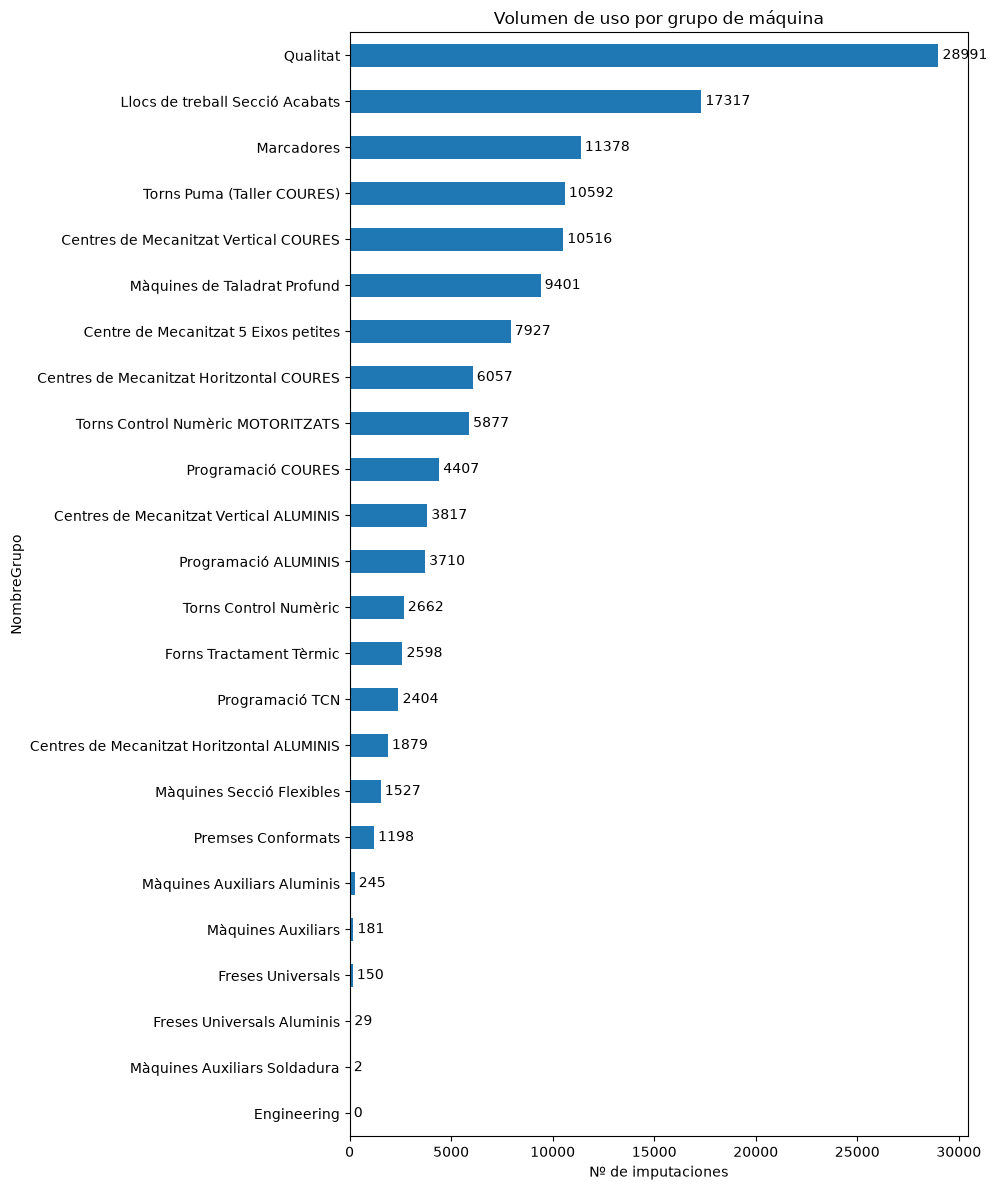

In [269]:
import matplotlib.pyplot as plt

uso_grupo = tabla_decision.groupby("NombreGrupo")["num_imputaciones"].sum().sort_values()

ax = uso_grupo.plot(kind="barh", figsize=(10, 12))
ax.bar_label(ax.containers[0], padding=3)

plt.xlabel("Nº de imputaciones")
plt.title("Volumen de uso por grupo de máquina")
plt.tight_layout()
plt.show()

Podemos entender este volumnumen de imputaciones por grupo de máquinas como el mapa de mi población de estudio.   
De todo este total de grupos voy a prescindir de aquellos que no considero productivos, es decir, aquellos que su productividad no dependende de la máquina. 

De los grupos de máquina disponibles se han excluido del análisis aquellos cuya naturaleza no se corresponde con operaciones de mecanizado productivo, por no ser coherentes con la variable objetivo del estudio. En concreto, se han descartado los grupos de ingeniería ("Engineering"), de programación ("Programació TCN", "Programació ALUMINIS" y "Programació COURES") y de calidad y acabados ("Qualitat" y "Llocs de treball Secció Acabats").

La razón de fondo es común a los tres bloques: la idoneidad de una asignación se infiere a partir de la desviación entre el tiempo real y el tiempo teórico de ejecución, y esa desviación solo constituye una medida válida de adecuación cuando existe una máquina concreta y un conjunto de recursos alternativos entre los que decidir. En las tareas de ingeniería y de programación (CAM, control numérico) el tiempo empleado depende fundamentalmente del factor humano y de la complejidad del trabajo a preparar, no de la máquina asignada, por lo que su desviación no informa sobre la idoneidad de ninguna asignación máquina-fase. De forma análoga, las actividades de control de calidad y de acabados constituyen operaciones de verificación y de tratamiento final que no forman parte del proceso de mecanizado cuya optimización persigue este trabajo.

In [270]:
grupos_no_productivos = [
    "Engineering",
    "Qualitat",
    "Llocs de treball Secció Acabats",
    "Programació TCN",
    "Programació ALUMINIS",
    "Programació COURES",
    "Marcadores",
]

# me quedo con todo MENOS esos grupos
mask_fuera = maquina_grupo["NombreGrupo"].isin(grupos_no_productivos)

print(f"Grupos que se eliminan: {sorted(maquina_grupo.loc[mask_fuera, 'NombreGrupo'].unique())}")
print(f"Máquinas que se van con ellos: {mask_fuera.sum()}")
print(f"maquina_grupo antes: {len(maquina_grupo)}")

maquina_grupo = maquina_grupo[~mask_fuera]
print(f"maquina_grupo después: {len(maquina_grupo)}")

Grupos que se eliminan: ['Engineering', 'Llocs de treball Secció Acabats', 'Marcadores', 'Programació ALUMINIS', 'Programació COURES', 'Programació TCN', 'Qualitat']
Máquinas que se van con ellos: 35
maquina_grupo antes: 111
maquina_grupo después: 76


In [271]:
# volumen de uso por máquina tras limpieza de grupos no productivos
uso = df_imputations_limpieza["smNodoId"].value_counts().rename("num_imputaciones")

tabla_decision = maquina_grupo.merge(
    uso, left_on="CodigoMaquina", right_index=True, how="left"
).sort_values("num_imputaciones", ascending=False)

uso_grupo = tabla_decision.groupby("NombreGrupo")["num_imputaciones"].sum().sort_values()

display(uso_grupo)

NombreGrupo
Màquines Auxiliars Soldadura                      2.0
Freses Universals Aluminis                       29.0
Freses Universals                               150.0
Màquines Auxiliars                              181.0
Màquines Auxiliars Aluminis                     245.0
Premses Conformats                             1198.0
Màquines Secció Flexibles                      1527.0
Centres de Mecanitzat Horitzontal ALUMINIS     1879.0
Forns Tractament Tèrmic                        2598.0
Torns Control Numèric                          2662.0
Centres de Mecanitzat Vertical ALUMINIS        3817.0
Torns Control Numèric MOTORITZATS              5877.0
Centres de Mecanitzat Horitzontal COURES       6057.0
Centre de Mecanitzat 5 Eixos petites           7927.0
Màquines de Taladrat Profund                   9401.0
Centres de Mecanitzat Vertical COURES         10516.0
Torns Puma (Taller COURES)                    10592.0
Name: num_imputaciones, dtype: float64

El patrón COURES vs ALUMINIS: las familias de cobre tienen mucho más volumen que las de aluminio (Vertical COURES 3.265 vs ALUMINIS 799). Dice algo sobre el mix de producción de esta planta — dato de contexto útil para la memoria.

Grupos de Máquinas a Manipular en base sus imputaciones:
- Màquines Auxiliars Soldadura: volumen insuficiente de imputaciones, descartamos el grupo. 
- Freses Universals Aluminis: volumen insuficiente de imputaciones, descartar del grupo. 
- Màquines Auxiliars: no tienen suficiente volumen de imputaciones.
- Freses Universals: no tienen suficiente volumne de imputaciones. 

In [272]:
grupos_a_descartar = [
    "Màquines Auxiliars Soldadura",
    "Freses Universals Aluminis",
    "Màquines Auxiliars", 
    "Freses Universals"
]

mask_fuera = maquina_grupo["NombreGrupo"].isin(grupos_a_descartar)

print(f"Maquinas que se eliminan: {mask_fuera.sum()}")
print(f"maquina_grupo antes: {len(maquina_grupo)}")

maquina_grupo = maquina_grupo[~mask_fuera]
print(f"maquina_grupo después: {len(maquina_grupo)}")

Maquinas que se eliminan: 38
maquina_grupo antes: 76
maquina_grupo después: 38


In [273]:
maquinas_finales = maquina_grupo["CodigoMaquina"].unique()
imput_finales = df_imputations_limpieza[df_imputations_limpieza["smNodoId"].isin(maquinas_finales)]

print(f"Imputaciones del dataset original: {df_imputations_limpieza.shape[0]}")
print(f"Imputaciones en grupos productivos finales: {len(imput_finales)}")
print(f"Eliminadas en total: {df_imputations_limpieza.shape[0] - len(imput_finales)}")

Imputaciones del dataset original: 140485
Imputaciones en grupos productivos finales: 64296
Eliminadas en total: 76189


Ahora voy a inspeccionar el numero de maquinas en los grupos de máquinas.

In [274]:
resumen_familia = maquina_grupo.groupby("NombreGrupo").agg(
    n_maquinas=("CodigoMaquina", "nunique"),
).sort_values("n_maquinas", ascending=False)

print(resumen_familia)
print()
print(f"Total de famílias {len(resumen_familia)}")

                                            n_maquinas
NombreGrupo                                           
Màquines Secció Flexibles                            5
Premses Conformats                                   5
Forns Tractament Tèrmic                              4
Centres de Mecanitzat Vertical COURES                4
Centre de Mecanitzat 5 Eixos petites                 4
Centres de Mecanitzat Horitzontal COURES             3
Centres de Mecanitzat Vertical ALUMINIS              3
Torns Control Numèric MOTORITZATS                    3
Torns Puma (Taller COURES)                           2
Màquines de Taladrat Profund                         2
Centres de Mecanitzat Horitzontal ALUMINIS           1
Màquines Auxiliars Aluminis                          1
Torns Control Numèric                                1

Total de famílias 13


Grupos de máquinas a manipular en base a su número de máquinas:
- Centres de Mecanitzat Horitzontal ALUMINIS: solo cuentan con una máquina, descartamos.
- Màquines Auxiliars Aluminis: solo cuentan con una máquina, descartamos.
> Al haber solo una máquina no hay posibilidad de elección dentro de la familia. 
- Torns Control Numèric: solo cuentan con una máquina, vamos a juntarla con la familia de `Torns Control Numèric MOTORITZATS` creando una familia que se llame `Torns Control Numèric`. 
- Forns Tractament Tèrmic: hablando con producción deduzco que aunque haya 4 máquinas en el sistema, realmente en taller solo se emplea 1, descarto la familia. 


In [275]:
# 1. Fusión de los tornos CNC
print(f"Antes de fusionar:")
print(f"  'Torns Control Numèric':            {(maquina_grupo['NombreGrupo'] == 'Torns Control Numèric').sum()} máquinas")
print(f"  'Torns Control Numèric MOTORITZATS': {(maquina_grupo['NombreGrupo'] == 'Torns Control Numèric MOTORITZATS').sum()} máquinas")

# máscara de las filas del grupo motorizado (antes de renombrar)
mask_motor = maquina_grupo["NombreGrupo"] == "Torns Control Numèric MOTORITZATS"

# unifico nombre, código e ID hacia los del grupo NO motorizado
maquina_grupo.loc[mask_motor, "NombreGrupo"] = "Torns Control Numèric"
maquina_grupo.loc[mask_motor, "CodigoGrupo"] = "TCN"          # <-- el código real del grupo no motorizado
maquina_grupo.loc[mask_motor, "IDGrupo"] = "id_tcn"            # <-- el ID real del grupo no motorizado

print(f"Después de fusionar:")
print(f"  'Torns Control Numèric' (fusionado): {(maquina_grupo['NombreGrupo'] == 'Torns Control Numèric').sum()} máquinas")
print(f"  Códigos de grupo distintos (debe ser 1): {maquina_grupo[maquina_grupo['NombreGrupo'] == 'Torns Control Numèric']['CodigoGrupo'].nunique()}")
# 2. Descarte de familias monomáquina
grupos_a_descartar = [
    "Centres de Mecanitzat Horitzontal ALUMINIS",
    "Màquines Auxiliars Aluminis",
    "Forns Tractament Tèrmic"
]
print(f"Antes de descartar:")
print(f"  Máquinas en maquina_grupo: {len(maquina_grupo)}")
for g in grupos_a_descartar:
    print(f"  '{g}': {(maquina_grupo['NombreGrupo'] == g).sum()} máquinas")

maquina_grupo = maquina_grupo[~maquina_grupo["NombreGrupo"].isin(grupos_a_descartar)]

print(f"Después de descartar:")
print(f"  Máquinas en maquina_grupo: {len(maquina_grupo)}")

Antes de fusionar:
  'Torns Control Numèric':            1 máquinas
  'Torns Control Numèric MOTORITZATS': 3 máquinas
Después de fusionar:
  'Torns Control Numèric' (fusionado): 4 máquinas
  Códigos de grupo distintos (debe ser 1): 1
Antes de descartar:
  Máquinas en maquina_grupo: 38
  'Centres de Mecanitzat Horitzontal ALUMINIS': 1 máquinas
  'Màquines Auxiliars Aluminis': 1 máquinas
  'Forns Tractament Tèrmic': 4 máquinas
Después de descartar:
  Máquinas en maquina_grupo: 32


In [276]:
# Reviso de nuevo como quedan las familias:
resumen_familia = maquina_grupo.groupby("NombreGrupo").agg(
    n_maquinas=("CodigoMaquina", "nunique"),
).sort_values("n_maquinas", ascending=False)

print(resumen_familia)
print("")
print(f"Total de familias: {len(resumen_familia)}")

                                          n_maquinas
NombreGrupo                                         
Màquines Secció Flexibles                          5
Premses Conformats                                 5
Centre de Mecanitzat 5 Eixos petites               4
Torns Control Numèric                              4
Centres de Mecanitzat Vertical COURES              4
Centres de Mecanitzat Horitzontal COURES           3
Centres de Mecanitzat Vertical ALUMINIS            3
Màquines de Taladrat Profund                       2
Torns Puma (Taller COURES)                         2

Total de familias: 9


Tengo ya la tabla de maquinas y su grupo limpia, paso a guardarla en local:

In [277]:
maquina_grupo.to_parquet("res//procesed/maquina_grupo.parquet")
display(maquina_grupo.sample(1))

,IDMaquina,CodigoMaquina,NombreMaquina,IDGrupo,CodigoGrupo,NombreGrupo
83,afe5eefa-f79c-449f-858e-b86d84344928,CM01,CHO MX60HB OKUMA,05a696bb-8ad5-4b76-af4f-7bd8112857e6,CH,Centres de Mecanitzat Horitzontal COURES


In [278]:
print(f"Valores nulos en la tabla: {maquina_grupo.isna().sum()}") 

Valores nulos en la tabla: IDMaquina        0
CodigoMaquina    0
NombreMaquina    0
IDGrupo          0
CodigoGrupo      0
NombreGrupo      0
dtype: int64


Tras haber creado una tabla `df_FASE_final` donde se encuentran todas las imputaciones con las que trabajaré, vamos a comprobar que todas las maquinas de `maquinas_grupo` tengan imputaciones:

In [279]:
df_FASE_final = pd.read_parquet("res//procesed/df_FASE_final.parquet")
display(df_FASE_final.sample(1))

,SmFaseUid,MaquinaDominante,smOrdenId,smMaterialId,smFaseNme,smOrdenNme,MinutosReal_total,MinutosPreparacion_total,MinutosProduccion_total,n_imputaciones,IDMaquina,NombreMaquina,IDGrupo,CodigoGrupo,NombreGrupo,IDMOTask,IDManufacturingOrder,Description,PreparationTime,ExecutionTime,ProductEntry,MaterialExit,IDUsualTask,Quantity,ManualStartDate,RealEndDate,MESEntityId
6970,674329db-b0ee-44b2-9fd0-bed8bcea76a7,CM05,OF2600144,BR1XA3X0049,CHO-PI,COOPER PART Arm MD639203S,69.05,69.05,0.0,2,9835df18-f376-4d2c-a1fc-dea39221366f,CH MAK. a81,05a696bb-8ad5-4b76-af4f-7bd8112857e6,CH,Centres de Mecanitzat Horitzontal COURES,f2568dae-a5d2-4cfc-b5e2-6345e8d84897,b2942ea2-68da-4bd6-8f87-b1855268fb1c,Mecanitzar Pinola al CH,61.0,50.0,0.0,0.0,07ce2977-b83c-4ce6-a32c-6675d626d3c9,2.0,2026-01-27 14:09:00.000,2026-02-02 00:00:00.000,674329db-b0ee-44b2-9fd0-bed8bcea76a7


In [280]:
maquinas_maestro = set(maquina_grupo["CodigoMaquina"])
maquinas_con_fases = set(df_FASE_final["MaquinaDominante"])

sin_imputaciones = maquinas_maestro - maquinas_con_fases

print(f"Máquinas en el maestro: {len(maquinas_maestro)}")
print(f"Máquinas con fases: {len(maquinas_con_fases)}")
print(f"Máquinas SIN ninguna fase: {len(sin_imputaciones)}")
if sin_imputaciones:
    print(maquina_grupo[maquina_grupo["CodigoMaquina"].isin(sin_imputaciones)][["CodigoMaquina", "NombreMaquina", "NombreGrupo"]].to_string(index=False))

Máquinas en el maestro: 32
Máquinas con fases: 28
Máquinas SIN ninguna fase: 4
CodigoMaquina          NombreMaquina               NombreGrupo
         PM01       Premsa Manual           Premses Conformats
         PH05       Premsa  DEM DEM  Màquines Secció Flexibles
         MM01 Màquina de Matxacar           Premses Conformats
         MC01              MAQ.CORV.        Premses Conformats
